# Part 4 — Model Training & Comparison

## 4. Model Training & Comparison

In [7]:
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb
import time

models = {
    'Extra Trees':    ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Random Forest':  RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost':        xgb.XGBClassifier(n_estimators=200, random_state=42,
                                         eval_metric='mlogloss', n_jobs=-1),
    'KNN':            KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Logistic Reg':   LogisticRegression(max_iter=500, random_state=42, n_jobs=-1),
}

results = {}
for name, model in models.items():
    print(f"Training {name}...")
    t0 = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - t0
    acc = accuracy_score(y_test, model.predict(X_test))
    results[name] = {'accuracy': acc, 'time': round(elapsed, 2), 'model': model}
    print(f"  Accuracy: {acc:.4f} | Time: {elapsed:.2f}s")

results_df = pd.DataFrame({k: {'Accuracy': v['accuracy'], 'Time (s)': v['time']}
                            for k, v in results.items()}).T.sort_values('Accuracy', ascending=False)
print("\nSUMMARY:")
print(results_df.to_string())

Training Extra Trees...
  Accuracy: 0.8873 | Time: 7.79s
Training Random Forest...
  Accuracy: 0.8858 | Time: 8.60s
Training XGBoost...
  Accuracy: 0.8860 | Time: 10.11s
Training KNN...
  Accuracy: 0.8111 | Time: 0.00s
Training Logistic Reg...
  Accuracy: 0.6962 | Time: 5.16s

SUMMARY:
               Accuracy  Time (s)
Extra Trees    0.887328      7.79
XGBoost        0.885954     10.11
Random Forest  0.885802      8.60
KNN            0.811145      0.00
Logistic Reg   0.696183      5.16


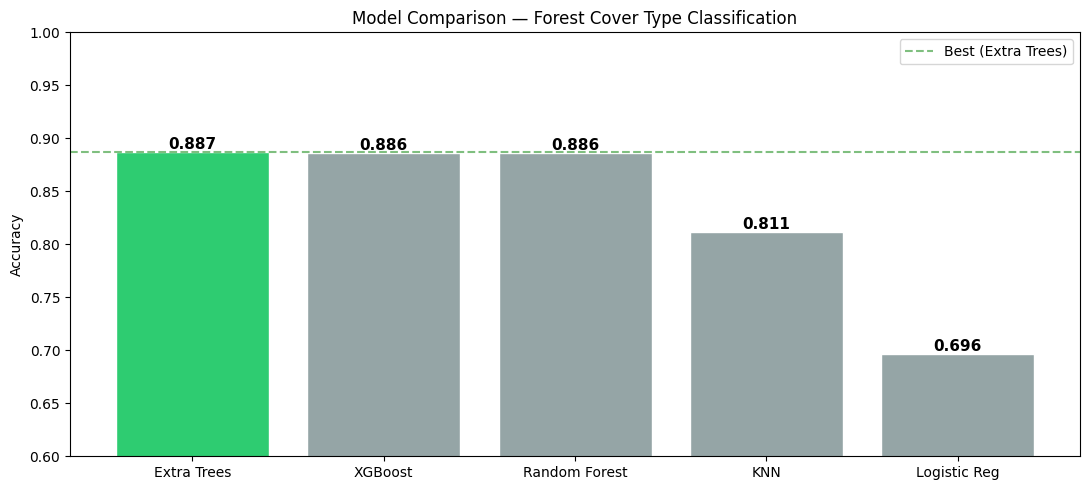

In [8]:
# Model comparison bar chart
plt.figure(figsize=(11, 5))
colors = ['#2ecc71' if n == 'Extra Trees' else '#95a5a6' for n in results_df.index]
bars = plt.bar(results_df.index, results_df['Accuracy'].astype(float), color=colors, edgecolor='white')
for bar, val in zip(bars, results_df['Accuracy'].astype(float)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
plt.ylabel('Accuracy')
plt.title('Model Comparison — Forest Cover Type Classification')
plt.ylim(0.6, 1.0)
plt.axhline(y=results['Extra Trees']['accuracy'], color='green',
            linestyle='--', alpha=0.5, label='Best (Extra Trees)')
plt.legend()
plt.tight_layout()
plt.show()